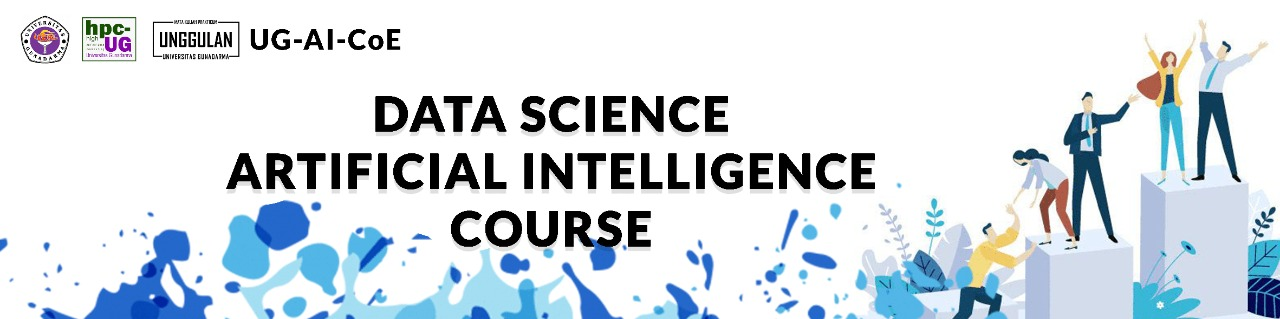

# Hands-On
---
Hands-On ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

### Daftar Isi:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Deployment

#### 1. Business Understanding

Dataset yang digunakan berisi informasi mengenai penerbangan, yang meliputi nomor penerbangan, waktu atau durasi penerbangan, jarak penerbangan, maskapai, bandara asal, bandara tujuan, dan hari dalam satu minggu. Pada proses clustering, hanya variabel `Time` dan `Length` yang digunakan sebagai fitur, yaitu durasi penerbangan dan jarak penerbangan.

Permasalahan yang ingin diselesaikan adalah bagaimana menemukan kelompok penerbangan yang memiliki karakteristik serupa berdasarkan durasi dan jarak penerbangan tanpa menentukan kelompok tersebut terlebih dahulu.

Karena pendekatan yang digunakan merupakan Unsupervised Learning, tidak terdapat variabel target yang harus diprediksi. Model akan mengidentifikasi pola atau struktur yang terdapat secara alami pada data berdasarkan kemiripan karakteristik durasi dan jarak penerbangan.

Tujuan analisis adalah:

* Mengidentifikasi pola atau kelompok penerbangan berdasarkan karakteristik durasi dan jarak penerbangan.
* Membandingkan hasil clustering menggunakan algoritma K-Means, Hierarchical Clustering, dan DBSCAN.
* Menentukan algoritma clustering terbaik berdasarkan metrik evaluasi, yaitu Silhouette Score dan Davies-Bouldin Index.
* Menginterpretasikan karakteristik masing-masing cluster berdasarkan durasi dan jarak penerbangan untuk memahami perbedaan karakteristik antar kelompok penerbangan.

In [1]:
# Import library pandas untuk manipulasi data
import pandas as pd

# Membaca dataset
df = pd.read_csv('delay_maskapai_unsupervised.csv')

# Menampilkan 5 data pertama
df.head()

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek
0,320.0,870.0,180.0,CO,IAH,PHX,5
1,3045.0,365.0,66.0,OO,DSM,MKE,2
2,1560.0,740.0,257.0,DL,SEA,CVG,7
3,1156.0,595.0,235.0,WN,SNA,MDW,7
4,1873.0,530.0,133.0,CO,IAH,MCO,6


#### 2. Data Understanding

Tahap Data Understanding bertujuan untuk memahami struktur, tipe data, jumlah data, serta karakteristik awal dari dataset.

Tahap ini penting dilakukan sebelum pemodelan karena kualitas model clustering sangat bergantung pada kualitas dan representasi data yang digunakan.

In [2]:
# Melihat ukuran dataset
df.shape

(10787, 7)

In [3]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10787 entries, 0 to 10786
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Flight       10787 non-null  float64
 1   Time         10787 non-null  float64
 2   Length       10787 non-null  float64
 3   Airline      10787 non-null  object 
 4   AirportFrom  10787 non-null  object 
 5   AirportTo    10787 non-null  object 
 6   DayOfWeek    10787 non-null  int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 590.0+ KB


Dataset terdiri dari 10.787 observasi dan 7 variabel. Variabel tersebut terdiri dari variabel numerik dan kategorikal.

In [4]:
# Melihat statistik deskriptif dari dataset
df.describe()

,Flight,Time,Length,DayOfWeek
count,10787.000000,10787.000000,10787.000000,10787.000000
mean,2435.506999,803.193566,133.346621,3.895430
std,2071.935213,276.976027,71.598884,1.923294
min,1.000000,15.000000,29.000000,1.000000
25%,720.000000,567.000000,81.000000,2.000000
50%,1798.000000,795.000000,116.000000,4.000000
75%,3785.500000,1035.000000,164.000000,5.000000
max,7812.000000,1439.000000,655.000000,7.000000


In [5]:
# Melihat statistik deskriptif untuk variabel kategorikal
df.describe(include="object")

,Airline,AirportFrom,AirportTo
count,10787,10787,10787
unique,18,270,265
top,WN,ATL,ATL
freq,1887,687,708


Berdasarkan hasil dari fungsi `describe()`, nilai `count` pada variabel `Flight`, `Time`, `Length`, `DayOfWeek`, `Airline`, `AirportFrom`, dan `AirportTo` masing-masing berjumlah 10.787. Jumlah tersebut sama dengan total observasi yang terdapat pada dataset, yaitu 10.787 data.

Hal ini menunjukkan bahwa pada variabel numerik tersebut tidak terdapat missing value, karena seluruh baris memiliki nilai yang terisi.

#### Exploratory Data Analysis (EDA)

In [6]:
# Import library matplotlib dan seaborn untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

Salah satu eksplorasi awal dilakukan dengan melihat hubungan antara variabel `Length` dan `Time` menggunakan scatterplot.

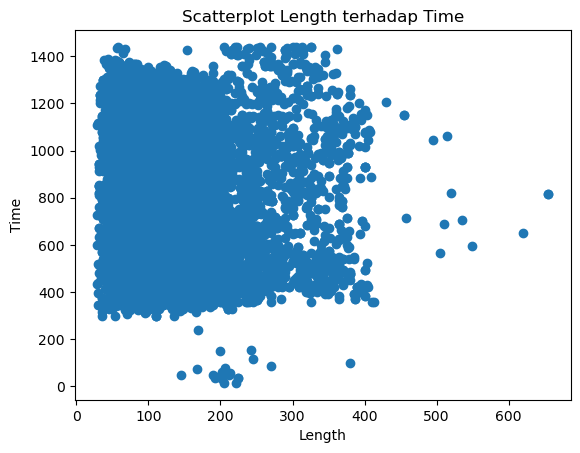

In [7]:
plt.scatter(
    df["Length"],
    df["Time"]
    )

plt.xlabel("Length")
plt.ylabel("Time")
plt.title("Scatterplot Length terhadap Time")
plt.show()

Berdasarkan scatterplot tersebut, persebaran data belum menunjukkan kelompok yang terbentuk secara jelas. Visualisasi ini memberikan gambaran awal mengenai hubungan antara durasi penerbangan (Time) dan jarak penerbangan (Length). Meskipun terdapat pola persebaran tertentu, batas antar kelompok belum terlihat secara jelas. Oleh karena itu, diperlukan proses clustering untuk mengidentifikasi kelompok penerbangan berdasarkan kemiripan karakteristik lama dan jarak penerbangan.

#### 3. Data Preparation

Proses clustering hanya menggunakan dua variabel numerik, yaitu `Time` dan `Length`.

In [9]:
# Fitur yang digunakan
features = [
    "Time",
    "Length"
]

X = df[features]

Selanjutnya, dilakukan standardisasi terhadap kedua fitur agar memiliki skala yang sebanding. Hal ini penting karena perbedaan skala dapat memengaruhi perhitungan jarak pada proses clustering.

In [10]:
# Import library Standard Scaler
from sklearn.preprocessing import StandardScaler

In [11]:
# Pre-processing data

scaler = StandardScaler()
df[['Time','Length']] = scaler.fit_transform(df[['Time','Length']])
scaled_data = df[['Time','Length']]

scaled_data.head()

,Time,Length
0,0.241211,0.651624
1,-1.582136,-0.940654
2,-0.228166,1.727109
3,-0.751701,1.419828
4,-0.986389,-0.004841


#### 4. Modeling

Setelah tahap preprocessing, data yang telah melalui proses standardisasi digunakan untuk melakukan clustering menggunakan tiga algoritma, yaitu K-Means, Hierarchical Clustering, dan DBSCAN.

##### **4.1. K-Means Clustering**

Untuk K-Means, jumlah cluster perlu ditentukan terlebih dahulu. Elbow Method dapat digunakan untuk melihat titik perubahan penurunan inertia.

Dalam K-Means, inertia mengukur seberapa jauh data dalam suatu cluster dari pusat clusternya (centroid). Semakin kecil inertia, berarti data dalam cluster semakin dekat dengan centroid.

In [12]:
# Tentukan jumlah cluster menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

c:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

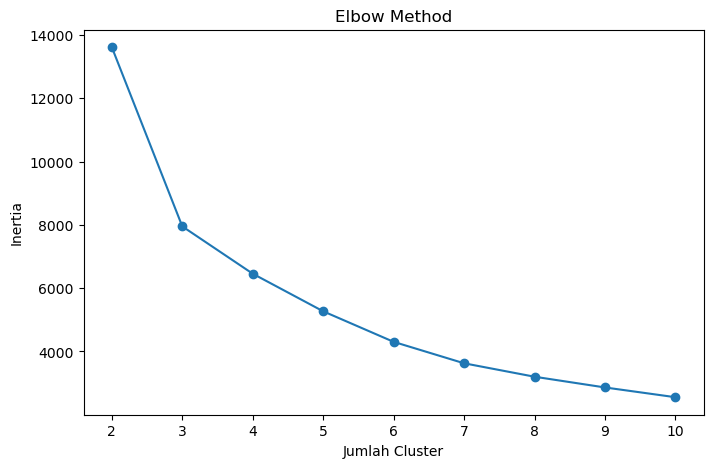

In [13]:
# Visualisasikan Elbow Method
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

Berdasarkan grafik di atas, jumlah cluster yang dipilih adalah 3 cluster (K=3). Hal ini terlihat dari perubahan kemiringan kurva pada K=3, di mana setelah titik tersebut penurunan inertia mulai melandai. Artinya, penambahan jumlah cluster di atas 3 memberikan pengurangan inertia yang relatif lebih kecil dibandingkan penambahan cluster sebelumnya.

Setelah menentukan K = 3 menggunakan metode Elbow, tahap berikutnya dapat diperkuat dengan Silhouette Score untuk melihat seberapa baik pemisahan cluster pada K-Means.

In [14]:
# Hitung Silhouette Score untuk beberapa jumlah cluster
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels)

    silhouette_scores.append(score)

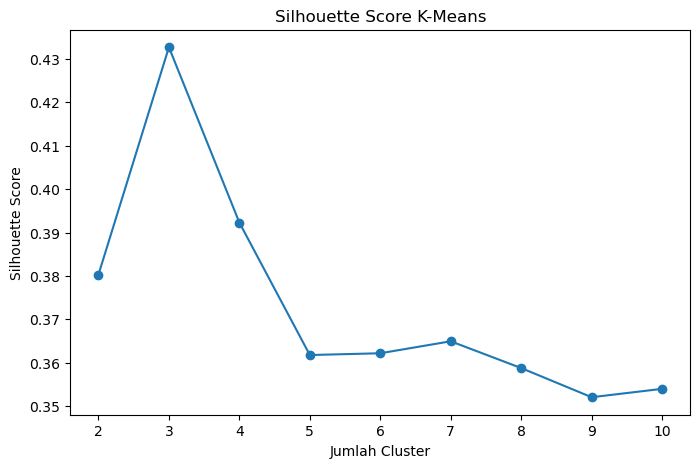

In [15]:
# Visualisasikan Silhouette Score
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score K-Means")

plt.show()

Berdasarkan hasil evaluasi menggunakan Silhouette Score, jumlah cluster kemudian dibandingkan untuk mengetahui kualitas pemisahan antar-cluster. Nilai Silhouette Score yang semakin mendekati 1 menunjukkan bahwa data dalam suatu cluster memiliki kemiripan yang tinggi, sementara jarak antar-cluster semakin baik. Hasil pengujian menunjukkan bahwa K = 3 memberikan struktur cluster yang baik. Hasil ini mendukung pemilihan 3 cluster yang sebelumnya diperoleh melalui metode Elbow. Oleh karena itu, K-Means digunakan dengan jumlah K = 3 pada tahap clustering.

Setelah mendapatkan jumlah cluster terbaik:

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"] = kmeans_labels
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    4732
1    4588
2    1467
Name: count, dtype: int64

# Deployment

Pada tahap ini, artefak yang dihasilkan dari proses pelatihan model, yaitu `scaler` dan model KMeans, diekspor dan disimpan ke dalam file menggunakan library Joblib. `Scaler` disimpan sebagai `scaler_maskapai.joblib`, sedangkan model KMeans disimpan sebagai `kmeans_maskapai.joblib`.

Proses ini bertujuan untuk menyimpan model dan preprocessing yang telah dilatih sehingga dapat digunakan kembali pada tahap deployment. Sehingga, sistem tidak perlu melakukan proses training ulang ketika model akan digunakan untuk melakukan prediksi atau pengelompokan data baru.

In [17]:
import joblib

# 1. Simpan scaler
joblib.dump(scaler, 'scaler_maskapai.joblib')

# 2. Simpan model KMeans yang sudah dilatih
joblib.dump(kmeans, 'kmeans_maskapai.joblib')

print("Ekstraksi berhasil!")

Ekstraksi berhasil!


## Contoh: Deployment Menggunakan Gradio

In [20]:
%pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [21]:
import gradio as gr

# 1. Memuat kembali artefak model
scaler = joblib.load('scaler_maskapai.joblib')
model_kmeans = joblib.load('kmeans_maskapai.joblib')


# 2. Membuat fungsi prediksi cluster
def prediksi_cluster(time_val, length_val):

    # Mengubah input pengguna menjadi DataFrame
    input_data = pd.DataFrame([[time_val, length_val]], columns=['Time', 'Length'])

    # Melakukan transformasi menggunakan scaler
    scaled_input = scaler.transform(input_data)

    # Menentukan cluster berdasarkan model KMeans
    cluster_result = model_kmeans.predict(scaled_input)[0]

    # Kembalikan hasil prediksi dalam bentuk teks
    return f"Penerbangan ini masuk ke dalam: Cluster {cluster_result}"


# 3. Membuat antarmuka pengguna dengan Gradio
antarmuka = gr.Interface(
    fn=prediksi_cluster, # Panggil fungsi di atas

    # Membuat form input Time dan Length
    inputs=[
        gr.Number(label="Time (Waktu Keterlambatan/Penerbangan)", value=100),
        gr.Number(label="Length (Jarak/Durasi Penerbangan)", value=500)
    ],

    # Menampilkan hasil prediksi
    outputs=gr.Textbox(label="Hasil Prediksi Machine Learning"),

    # Mengatur tampilan antarmuka
    title="✈️ Prediksi Cluster Delay Maskapai",
    description="Demo singkat untuk memprediksi kelompok penerbangan berdasarkan Waktu dan Jarak. Masukkan angka di bawah ini!"
)

# 4. Menjalankan deployment aplikasi
if __name__ == "__main__":
    # share=True akan secara otomatis men-generate link publik (.gradio.live)
    # yang bisa dibagikan ke orang lain!
    antarmuka.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/